# Introduction to Seaborn

This notebook is for **first-time students** who want to make clear, attractive plots from data in Python.

**What you will learn**

1. What Seaborn is and how it fits with Pandas and Matplotlib  
2. How to set a consistent look for your charts  
3. Scatter plots, line plots, and bar-style plots  
4. Plots for distributions (histograms, box plots)  
5. Heatmaps and small multiples (facets)  
6. Using color to show an extra variable (`hue`)

**What you should already know**

- A little Python (variables, lists, function calls)  
- The idea of a table of data (rows and columns), like a spreadsheet  

If you can use **Pandas** `DataFrame`s, you are ready. If not, think of each dataset below as a table: column names are variable names, each row is one observation.

## 1. Why Seaborn?

**Matplotlib** is Python’s foundational plotting library: flexible, but you write more code for labels, colors, and layout.

**Seaborn** builds on Matplotlib and is aimed at **statistical visualization**: it understands tidy tables (Pandas), picks sensible defaults, and makes it easy to compare groups with color (`hue`) or split charts (`col` / `row`).

**Pandas** holds the data; **Seaborn** draws the picture; **Matplotlib** is still underneath when you need fine control.

### Install (once per environment)

In a terminal:

`pip install seaborn pandas matplotlib`

Or with conda: `conda install seaborn pandas matplotlib`

In [1]:
# Standard imports for data + plotting
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducible random numbers when we create small demo data
import numpy as np

np.random.seed(42)

## 2. Themes and figure size

`sns.set_theme()` applies Seaborn’s default style (font, grid, colors). You can pass `style`, `palette`, `font_scale`, and more.

Matplotlib’s `plt.figure(figsize=(width, height))` sets the size in **inches** (width, height).

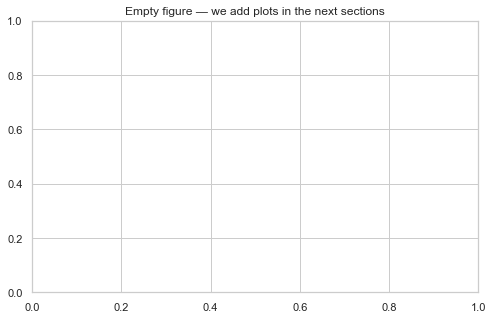

In [2]:
sns.set_theme(style="whitegrid", context="notebook")

plt.figure(figsize=(8, 5))
plt.title("Empty figure — we add plots in the next sections")
plt.show()

## 3. Tidy data and built-in practice datasets

Seaborn likes **tidy** (long-form) data: one row per observation, one column per variable.

`sns.load_dataset()` downloads small example tables (first time may require internet). We use **`tips`** (restaurant bills) and **`penguins`** (measurements by species).

In [3]:
tips = sns.load_dataset("tips")
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## 4. Scatter plots: two numeric columns

`sns.scatterplot` needs at least `data`, `x`, and `y` — all **column names** as strings.

**`hue`** splits points by a categorical column (e.g. smoker vs non-smoker) using different colors.

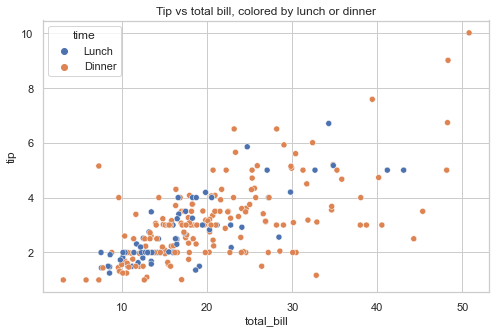

In [4]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=tips, x="total_bill", y="tip", hue="time")
plt.title("Tip vs total bill, colored by lunch or dinner")
plt.show()

## 5. Line plots: trend along one axis

Line plots connect points in **sorted order** along `x`. They are natural for time series or any ordered sequence.

Below we aggregate tips by day of week for a simple demo.

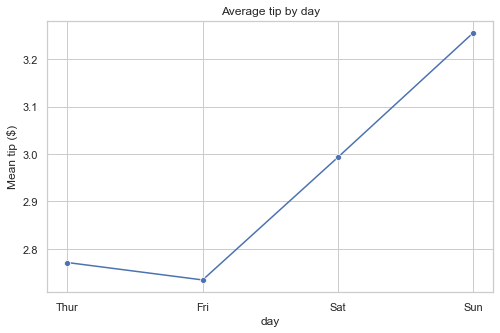

In [5]:
by_day = tips.groupby("day", observed=True)["tip"].mean().reset_index()
# Order days Monday–Sunday for readability (dataset only has Thu–Sun)
day_order = ["Thur", "Fri", "Sat", "Sun"]
by_day["day"] = pd.Categorical(by_day["day"], categories=day_order, ordered=True)
by_day = by_day.sort_values("day")

plt.figure(figsize=(8, 5))
sns.lineplot(data=by_day, x="day", y="tip", marker="o")
plt.title("Average tip by day")
plt.ylabel("Mean tip ($)")
plt.show()

## 6. Bar plots: comparing categories

- **`sns.barplot`**: shows an **aggregate** (default: **mean**) of a numeric variable per category. Error bars are a **confidence interval** by default.
- **`sns.countplot`**: counts how many rows fall in each category (no separate numeric column needed).

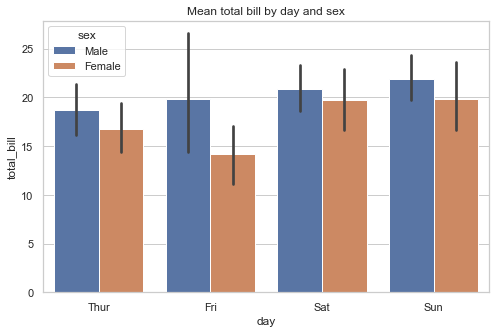

In [6]:
plt.figure(figsize=(8, 5))
sns.barplot(data=tips, x="day", y="total_bill", hue="sex", order=day_order)
plt.title("Mean total bill by day and sex")
plt.show()

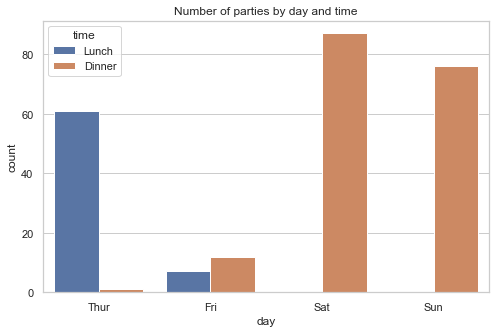

In [7]:
plt.figure(figsize=(8, 5))
sns.countplot(data=tips, x="day", hue="time", order=day_order)
plt.title("Number of parties by day and time")
plt.show()

## 7. Distributions: histograms and density

**`sns.histplot`**: bars show how often values fall in bins (a **histogram**). `kde=True` adds a smooth **density** curve.

**`sns.kdeplot`**: only the smooth density estimate (no bars).

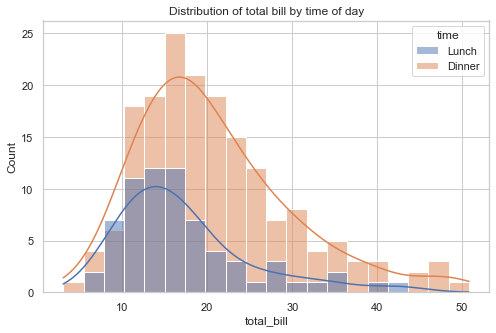

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(data=tips, x="total_bill", hue="time", kde=True, bins=20)
plt.title("Distribution of total bill by time of day")
plt.show()

## 8. Box and violin plots: compare distributions across groups

- **Box plot**: median, quartiles, and whiskers; points beyond whiskers are possible **outliers**.
- **Violin plot**: combines a box-like summary with a **mirrored density** shape.

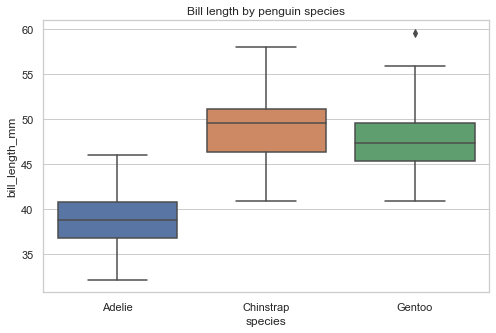

In [9]:
penguins = sns.load_dataset("penguins")
penguins = penguins.dropna(subset=["bill_length_mm", "species"])

plt.figure(figsize=(8, 5))
sns.boxplot(data=penguins, x="species", y="bill_length_mm")
plt.title("Bill length by penguin species")
plt.show()

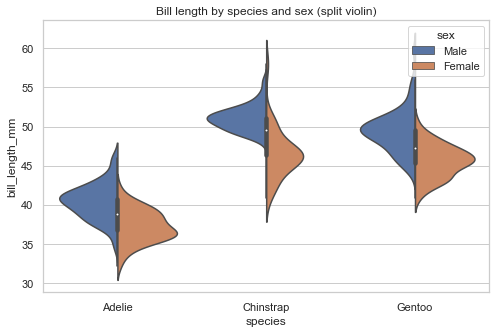

In [10]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=penguins, x="species", y="bill_length_mm", hue="sex", split=True)
plt.title("Bill length by species and sex (split violin)")
plt.show()

## 9. Heatmaps: matrix as a color grid

Heatmaps need a **2D** table of numbers (e.g. correlation matrix). `annot=True` prints the values in each cell.

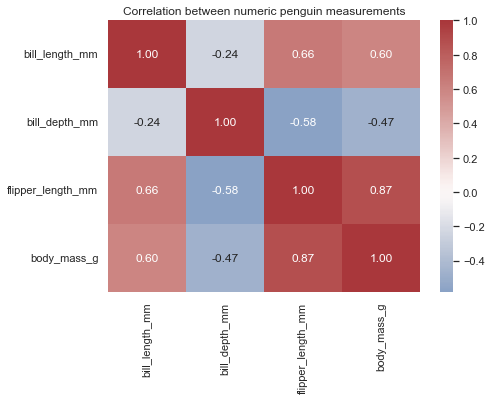

In [11]:
numeric = penguins.select_dtypes(include="number")
corr = numeric.corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlation between numeric penguin measurements")
plt.show()

## 10. Small multiples with `relplot` (figure-level)

Many Seaborn functions come in two flavors:

- **Axes-level** (e.g. `scatterplot`): draws on the **current** Matplotlib axes.
- **Figure-level** (e.g. `relplot`): can create a **grid** of subplots with `col=` and/or `row=`.

`relplot` is a **relational** plot: use `kind="scatter"` (default) or `kind="line"`.

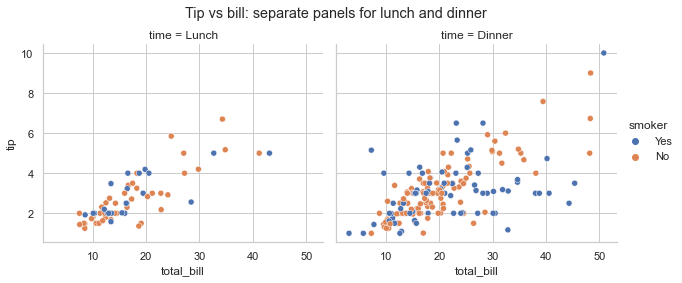

In [12]:
g = sns.relplot(
    data=tips,
    x="total_bill",
    y="tip",
    col="time",
    hue="smoker",
    kind="scatter",
    height=4,
    aspect=1.1,
)
g.figure.subplots_adjust(top=0.85)
g.figure.suptitle("Tip vs bill: separate panels for lunch and dinner")
plt.show()

## 11. Color palettes (short tour)

You can set a **palette** name in many functions, or globally with `sns.set_palette()`.

Try **`"deep"`**, **`"muted"`**, **`"colorblind"`**, or **`"Set2"`** for categorical data.

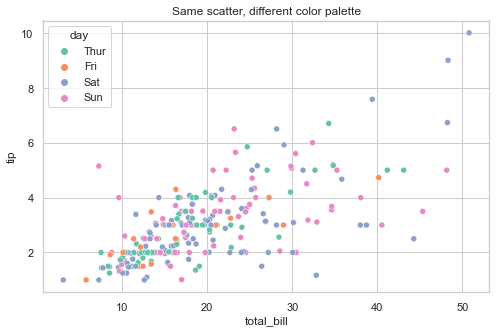

In [13]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=tips, x="total_bill", y="tip", hue="day", palette="Set2")
plt.title("Same scatter, different color palette")
plt.show()

## 12. Practice (try on your own)

1. Load **`iris`** with `sns.load_dataset("iris")`. Make a scatter plot of **`sepal_length`** vs **`petal_length`** with **`species`** as `hue`.
2. On `tips`, make a **`histplot`** of **`tip`** with **`sex`** as `hue`.
3. Use **`sns.pairplot`** on a small numeric subset of `penguins` (look up the docs: `pairplot` shows scatter plots for each pair of columns).

---

### Cheat sheet (functions used here)

| Goal | Function |
|------|----------|
| Scatter | `sns.scatterplot` |
| Line | `sns.lineplot` |
| Bar (mean by category) | `sns.barplot` |
| Count by category | `sns.countplot` |
| Histogram / counts | `sns.histplot` |
| Smooth density | `sns.kdeplot` |
| Box summary | `sns.boxplot` |
| Density + box | `sns.violinplot` |
| Correlation grid | `sns.heatmap` |
| Faceted scatter/line | `sns.relplot` |

Official tutorial: [seaborn.pydata.org/tutorial.html](https://seaborn.pydata.org/tutorial.html)